In [146]:
from sklearn.covariance import LedoitWolf
import os
import pickle
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import matplotlib.patches as patches
from joblib import Parallel, delayed

In [147]:
# TE - CARBON FRONTIERS OPTIMIZATION

# --- Utility functions ---
def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_shrink_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    Sigma_reg = Sigma_shrink + 1e-5 * np.eye(Sigma_shrink.shape[0])
    return nearest_psd(Sigma_reg), lw.shrinkage_

def run_sector_optimisation(sector_name, sector, R, cov_type="raw", cache_dir="cache"):
    os.makedirs(cache_dir, exist_ok=True)
    cache_file = f"{cache_dir}/{sector_name}_{cov_type}.pkl"

    # --- Load from cache if exists ---
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            return pickle.load(f)

    # --- Inputs ---
    w_bench = sector['weight_in_sector'].values
    c_vec = sector['Carbon Intensity'].values
    assert np.isclose(w_bench.sum(), 1.0)
    assert not np.isnan(c_vec).any()

    R_clean = R.drop(columns=['Date']).dropna()
    stock_labels = R_clean.columns

    # --- Choose covariance ---
    if cov_type == "raw":
        Sigma = sigma_raw_fn(R_clean)
        shrinkage_alpha = None
    elif cov_type == "shrink":
        Sigma, shrinkage_alpha = sigma_shrink_fn(R_clean)
    else:
        raise ValueError("cov_type must be 'raw' or 'shrink'")

    eigvals = np.linalg.eigvalsh(Sigma)
    smallest_eigs= np.sort(eigvals)[:5]
    rank = np.linalg.matrix_rank(Sigma)
    num_features = Sigma.shape[1]
    N = len(w_bench)

    # --- Optimisation loop ---
    te_caps_annual = np.linspace(0.002, 0.05, 100)
    
    # Ensure 0.02 (2%) is included
    if not np.isclose(te_caps_annual, 0.02).any():
        te_caps_annual = np.sort(np.append(te_caps_annual, 0.02))

    tracking_errors, carbon_reductions, weights_by_te = [], [], []

    for te_annual in te_caps_annual:
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(cp.Minimize(c_vec @ w), constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if prob.status not in ["optimal", "optimal_inaccurate"] or w.value is None:
            continue

        w_opt = w.value
        diff = w_opt - w_bench
        te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
        carbon_b = w_bench @ c_vec
        carbon_opt = w_opt @ c_vec
        reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100

        tracking_errors.append(te_real * 10000)
        carbon_reductions.append(reduction_pct)
        weights_by_te.append(w_opt)

    # --- Summary stats ---
    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)
    start_red, end_red = carbon_reductions_np[0], carbon_reductions_np[-1]
    idx_2pct = np.argmin(np.abs(tracking_errors_np - 200))
    reduction_at_2pct = carbon_reductions_np[idx_2pct]

    diagnostics = {
        "Sector": sector_name,
        "Num Features": num_features,
        "Covariance": cov_type,
        "Rank": rank,
        "Min_Eigval1": smallest_eigs[0],
        "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
        "Low Rank?": rank < num_features,
        "Not PSD?": eigvals.min() < -1e-6,
        "Shrinkage Alpha": shrinkage_alpha,
        "Start Reduction (%)": round(start_red, 2),
        "End Reduction (%)": round(end_red, 2),
        "Gain (%)": round(end_red - start_red, 2),
        "Reduction @2% TE (%)": round(reduction_at_2pct, 2),
    }

    result = {
        "sector_name": sector_name,
        "cov_type": cov_type,
        "diagnostics": diagnostics,
        "weights_by_te": weights_by_te,
        "tracking_errors": tracking_errors,
        "carbon_reductions": carbon_reductions,
        "w_bench": w_bench,                # add benchmark weights
        "stock_labels": list(stock_labels) # add stock labels
    }

    # --- Save to cache ---
    with open(cache_file, "wb") as f:
        pickle.dump(result, f)

    return result

In [148]:
def run_period(period_tag):
    print(f"=== Running period {period_tag} ===")

    #cache_dir = f"data/covariances/{period_tag}"
    cache_dir = f"cache/{period_tag}"
    os.makedirs(cache_dir, exist_ok=True)

    data_file = f"data/datasets/dataset_comp_{period_tag}.xlsx"
    log_file  = f"data/log_returns/sector_log_returns_comp_{period_tag}.xlsx"

    data = pd.read_excel(data_file)
    log_returns_all = pd.read_excel(log_file, sheet_name=None)

    results = []

    for sector_name in data['GICS Sector'].unique():
        print(sector_name)
        sector = data[data['GICS Sector'] == sector_name]
        R = log_returns_all[sector_name]

        # raw
        res_raw = run_sector_optimisation(sector_name, sector, R, cov_type="raw", cache_dir=cache_dir)
        results.append(res_raw)

        # shrink
        res_shrink = run_sector_optimisation(sector_name, sector, R, cov_type="shrink", cache_dir=cache_dir)
        results.append(res_shrink)

    # --- Combine diagnostics ---
    diagnostics_df = pd.DataFrame([r["diagnostics"] for r in results])

    # --- Combine full results ---
    combined_results = {
        r["sector_name"]: {
            "cov_type": r["cov_type"],
            "diagnostics": r["diagnostics"],
            "weights_by_te": r["weights_by_te"],
            "tracking_errors": r["tracking_errors"],
            "carbon_reductions": r["carbon_reductions"],
            "w_bench": r.get("w_bench"),
            "stock_labels": r.get("stock_labels")
        }
        for r in results
    }

    # --- Save results ---
    out_path = f"results/optimal_portfolios/optimal_portfolios_all_te_{period_tag}.pkl"
    with open(out_path, "wb") as f:
        pickle.dump(combined_results, f)
    print(f"✅ Saved results for {period_tag} to {out_path}")

    return diagnostics_df


In [149]:
time_periods = ["0322", "0622", "0922", "1221", "1222"]

all_diagnostics = []

for tag in time_periods:
    diag = run_period(tag)
    all_diagnostics.append(diag)

# Combine into one summary DataFrame
all_diag_df = pd.concat(all_diagnostics, keys=time_periods, names=["Period", "Index"]).reset_index()
all_diag_df.to_excel("results/optimal_portfolios/diagnostics_summary_all_periods.xlsx", index=False)
print("✅ Finished all periods.")


=== Running period 0322 ===
Consumer Discretionary
Health Care
Utilities
Information Technology
Real Estate
Materials
Industrials
Financials
Energy
Communication Services
Consumer Staples
✅ Saved results for 0322 to results/optimal_portfolios/optimal_portfolios_all_te_0322.pkl
=== Running period 0622 ===
Consumer Discretionary
Health Care
Utilities
Information Technology
Real Estate
Materials
Industrials
Financials
Energy
Communication Services
Consumer Staples
✅ Saved results for 0622 to results/optimal_portfolios/optimal_portfolios_all_te_0622.pkl
=== Running period 0922 ===
Consumer Discretionary
Health Care
Utilities
Information Technology
Real Estate
Materials
Industrials
Financials
Energy
Communication Services
Consumer Staples
✅ Saved results for 0922 to results/optimal_portfolios/optimal_portfolios_all_te_0922.pkl
=== Running period 1221 ===
Consumer Discretionary
Health Care
Utilities
Information Technology
Real Estate
Materials
Industrials
Financials
Energy
Communication Serv

In [150]:
TARGET_TE_BPS = 200    # 2% TE
K_NEIGHBORS    = 7     # use up to 7 closest TE points for the local fit (min 3)

def _local_slope_at_target(te_bps, red_pct, target_bps=200, k=7):
    """
    te_bps: array-like of TE in basis points (e.g., [10, 20, ..., 500])
    red_pct: array-like of carbon reduction in percent (e.g., [12.3, 13.1, ...])
    Returns (slope_pp_per_pctTE, Rstar_pct) where:
      slope units = percentage-point carbon per +1% TE  (pp / %TE)
      Rstar_pct   = carbon reduction (%) at target TE (via local linear fit)
    """
    te_bps = np.asarray(te_bps, float)
    red_pct = np.asarray(red_pct, float)

    # guard: need at least 3 points
    if len(te_bps) < 3:
        return np.nan, np.nan

    # choose k nearest points to target_bps
    order = np.argsort(np.abs(te_bps - target_bps))
    idx = order[:max(3, min(k, len(te_bps)))]
    X_te_pct = te_bps[idx] / 100.0  # convert bps -> % TE
    y = red_pct[idx]

    # robust linear fit y = a + b * TE(%)
    X = np.c_[np.ones(len(idx)), X_te_pct]
    a, b = np.linalg.lstsq(X, y, rcond=None)[0]
    Rstar = a + b * (target_bps / 100.0)
    slope = b
    return float(slope), float(Rstar)

In [151]:
# === Time periods you want to loop over ===
periods = ["1221", "0322", "0622", "0922", "1222"]

records = []  # this will store all results from all periods

for period in periods:
    print(f"\n=== Processing {period} ===")

    # 1️⃣ Load input data for that period
    data = pd.read_excel(f"data/datasets/dataset_comp_{period}.xlsx")
    log_returns_all = pd.read_excel(f"data/log_returns/sector_log_returns_comp_{period}.xlsx", sheet_name=None)

    # 2️⃣ Load your optimal portfolios result pickle for that period
    with open(f"results/optimal_portfolios/optimal_portfolios_all_te_{period}.pkl", "rb") as f:
        optimal_portfolios_all_te = pickle.load(f)

    # 3️⃣ Compute slope & R* for each sector
    TARGET_TE_BPS = 200
    K_NEIGHBORS = 7

    def _local_slope_at_target(te_bps, red_pct, target_bps=200, k=7):
        te_bps = np.asarray(te_bps, float)
        red_pct = np.asarray(red_pct, float)
        if len(te_bps) < 3:
            return np.nan, np.nan
        order = np.argsort(np.abs(te_bps - target_bps))
        idx = order[:max(3, min(k, len(te_bps)))]
        X_te_pct = te_bps[idx] / 100.0
        y = red_pct[idx]
        X = np.c_[np.ones(len(idx)), X_te_pct]
        a, b = np.linalg.lstsq(X, y, rcond=None)[0]
        Rstar = a + b * (target_bps / 100.0)
        slope = b
        return float(slope), float(Rstar)

    # 4️⃣ Loop through all sectors in that period
    rows = []
    for sector_name, metrics in optimal_portfolios_all_te.items():
        te_bps = np.asarray(metrics['tracking_errors'], float)
        red_pct = np.asarray(metrics['carbon_reductions'], float)

        df_tmp = pd.DataFrame({'te_bps': te_bps, 'red_pct': red_pct}) \
                   .sort_values('te_bps') \
                   .drop_duplicates(subset='te_bps', keep='last')

        slope, Rstar = _local_slope_at_target(df_tmp['te_bps'].values, df_tmp['red_pct'].values)
        rows.append({
            'Period': period,
            'Sector': sector_name,
            'Slope_at_2pct': slope,
            'Rstar_at_2pct': Rstar
        })

    df_period = pd.DataFrame(rows)
    records.append(df_period)  # ✅ store each period's results



=== Processing 1221 ===

=== Processing 0322 ===

=== Processing 0622 ===

=== Processing 0922 ===

=== Processing 1222 ===


In [152]:
frontier_df = pd.concat(records, ignore_index=True)

print(frontier_df.head())
print(frontier_df["Period"].unique())
frontier_df["Period"] = frontier_df["Period"].astype(str)
period_order = ["1221", "0322", "0622", "0922", "1222"]
frontier_df["Period"] = pd.Categorical(frontier_df["Period"], categories=period_order, ordered=True)


  Period                  Sector  Slope_at_2pct  Rstar_at_2pct
0   1221  Consumer Discretionary      20.348990      52.048897
1   1221             Health Care      18.764177      43.820981
2   1221               Utilities      14.484887      31.884343
3   1221  Information Technology       6.546151      62.670204
4   1221             Real Estate      12.632407      33.083793
['1221' '0322' '0622' '0922' '1222']


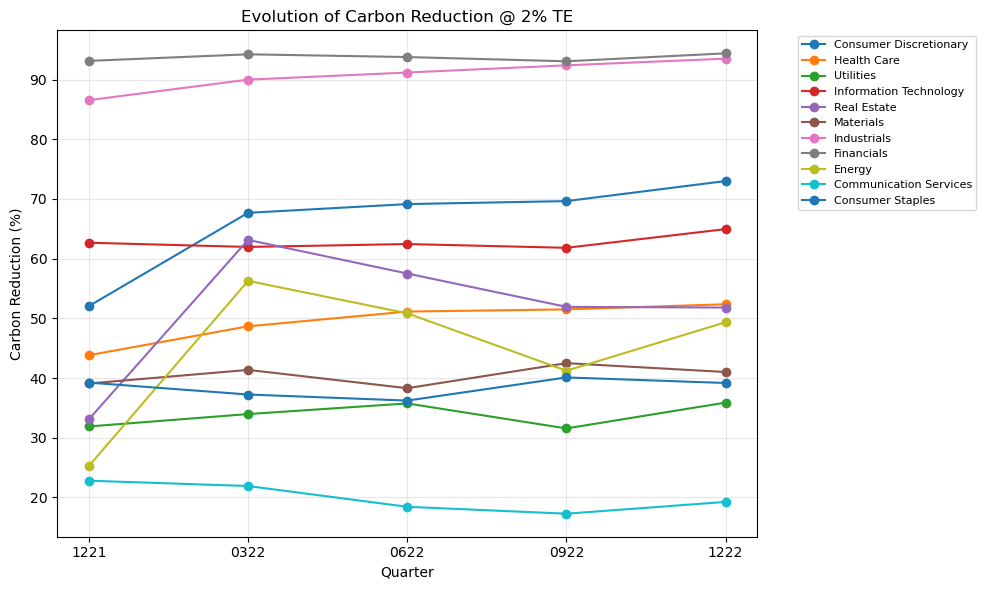

In [153]:
fig, ax = plt.subplots(figsize=(10,6))
for sector in frontier_df["Sector"].unique():
    sub = frontier_df[frontier_df["Sector"] == sector]
    ax.plot(sub["Period"], sub["Rstar_at_2pct"], marker='o', label=sector)
ax.set_title("Evolution of Carbon Reduction @ 2% TE")
ax.set_ylabel("Carbon Reduction (%)")
ax.set_xlabel("Quarter")
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

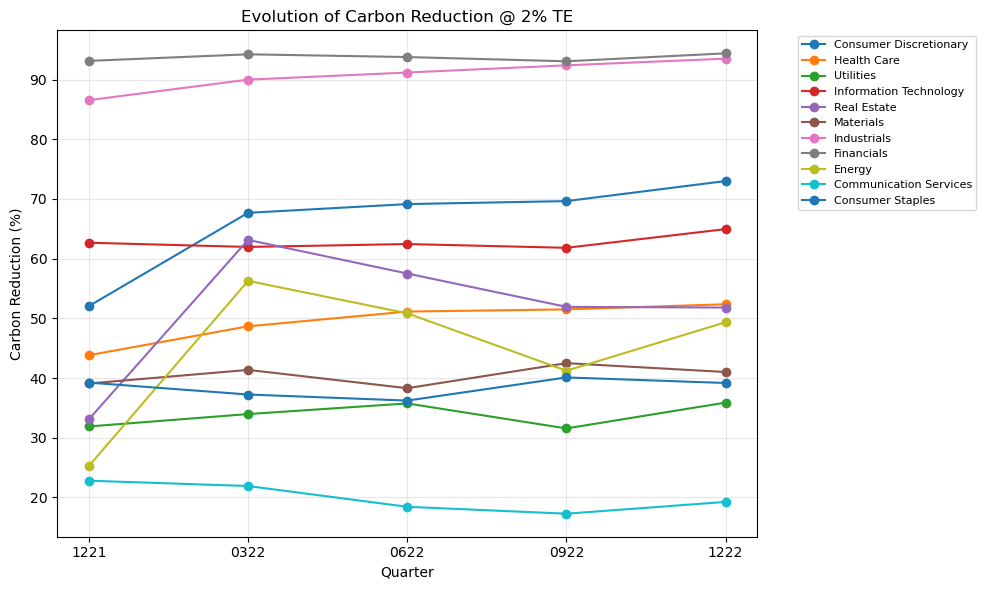

In [154]:
fig, ax = plt.subplots(figsize=(10,6))
for sector in frontier_df["Sector"].unique():
    sub = frontier_df[frontier_df["Sector"] == sector]
    ax.plot(sub["Period"], sub["Rstar_at_2pct"], marker='o', label=sector)
ax.set_title("Evolution of Carbon Reduction @ 2% TE")
ax.set_ylabel("Carbon Reduction (%)")
ax.set_xlabel("Quarter")
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [155]:
# --- CONFIG ---
periods = ["1221", "0322", "0622", "0922", "1222"]
TE_TARGET, TE_AUC_MAX, TE_WIN_BPS = 0.02, 0.05, 25

# --- METRIC HELPERS (same as before) ---
def _interp(te0, te_grid, c_grid):
    return float(np.interp(np.clip(te0, te_grid[0], te_grid[-1]), te_grid, c_grid))

def _prep_frontier(te_bps, cuts_pct):
    te = np.asarray(te_bps, float) / 10000.0
    c  = np.asarray(cuts_pct, float) / 100.0
    m  = np.isfinite(te) & np.isfinite(c)
    te, c = te[m], c[m]
    order = np.argsort(te)
    te, c = te[order], c[order]
    # collapse duplicates
    uniq_te = np.unique(te)
    uniq_c  = [np.nanmax(c[te == t]) for t in uniq_te]
    return uniq_te, np.array(uniq_c)

def _slope_at(te_grid, c_grid, te0, win_bps=25):
    h = win_bps / 10000.0
    tl, tr = np.clip([te0 - h, te0 + h], te_grid[0], te_grid[-1])
    if tr <= tl: return np.nan
    return (_interp(tr, te_grid, c_grid) - _interp(tl, te_grid, c_grid)) / (tr - tl)

def _elasticity_at(te_grid, c_grid, te0, win_bps=25):
    c0 = _interp(te0, te_grid, c_grid)
    s  = _slope_at(te_grid, c_grid, te0, win_bps)
    if c0 <= 0 or not np.isfinite(s): return np.nan
    return s * (te0 / c0)

def _auc_to(te_grid, c_grid, te_max):
    xs = np.unique(np.clip(np.r_[0.0, te_grid, te_max], 0, te_max))
    ys = np.array([_interp(x, te_grid, c_grid) for x in xs])
    return float(np.trapz(ys, xs))

def _te_for_cut(te_grid, c_grid, cut_frac):
    if c_grid[0] >= cut_frac: return 0.0
    if c_grid[-1] <  cut_frac: return np.nan
    idx = np.searchsorted(c_grid, cut_frac)
    if idx == 0: return te_grid[0]
    x0, x1, y0, y1 = te_grid[idx-1], te_grid[idx], c_grid[idx-1], c_grid[idx]
    return float(x0 + (cut_frac - y0) * (x1 - x0) / (y1 - y0))

def _minmax(x):
    x = np.asarray(x, float)
    if len(x) < 2 or np.all(~np.isfinite(x)): return np.full_like(x, np.nan)
    lo, hi = np.nanmin(x), np.nanmax(x)
    return (x - lo) / (hi - lo) if hi > lo else np.zeros_like(x)

# --- MAIN COMPUTATION ---
records = []

for period in periods:
    fname = f"results/optimal_portfolios/optimal_portfolios_all_te_{period}.pkl"
    if not os.path.exists(fname):
        print(f"⚠️ Missing file: {fname}")
        continue

    with open(fname, "rb") as f:
        sector_data = pickle.load(f)

    for sector, d in sector_data.items():
        te_bps = d.get("tracking_errors", [])
        c_pct  = d.get("carbon_reductions", [])
        if len(te_bps) < 3:
            continue

        # Prepare frontier
        te, c = _prep_frontier(te_bps, c_pct)  # te in bps, c in % reduction
        te_frac = te / 10000 if np.nanmax(te) > 1 else te  # ensure in decimals (0.02, 0.05 etc.)

        # Compute other metrics on normalized carbon reduction curve
        c_norm = c / np.nanmax(c) if np.nanmax(c) > 0 else c

        slope2 = _slope_at(te_frac, c_norm, TE_TARGET, TE_WIN_BPS)
        elast2 = _elasticity_at(te_frac, c_norm, TE_TARGET, TE_WIN_BPS)
        auc5   = _auc_to(te_frac, c_norm, TE_AUC_MAX) / TE_AUC_MAX

        # ✅ Use *raw carbon reduction* (in %) at TE = 5%
        max5   = _interp(TE_AUC_MAX, te_frac, c)

        # Use normalized c only for TE_for_50pctCut and smoothness
        te50   = _te_for_cut(te_frac, c_norm, 0.50)

        records.append({
            "Sector": sector,
            "Period": period,
            "Slope_at_2pct": slope2,
            "Elasticity_at_2pct": elast2,
            "AUC_to_5pctTE": auc5,
            "MaxCut_at_5pctTE": max5,
            "TE_for_50pctCut": te50
        })

# Build full dataframe
df = pd.DataFrame(records)
print(df.head())


                   Sector Period  Slope_at_2pct  Elasticity_at_2pct  \
0  Consumer Discretionary   1221      27.115692            0.779651   
1             Health Care   1221      22.881450            0.856608   
2               Utilities   1221      21.423050            0.909149   
3  Information Technology   1221       9.224101            0.222560   
4             Real Estate   1221      21.757015            0.767943   

   AUC_to_5pctTE  MaxCut_at_5pctTE  TE_for_50pctCut  
0       0.699374          0.748447         0.013154  
1       0.602060          0.820302         0.018509  
2       0.551003          0.676638         0.021348  
3       0.776854          0.756267         0.007227  
4       0.602535          0.584026         0.017074  


In [156]:
results = []
for period, grp in df.groupby("Period"):
    temp = grp.copy()
    for col in ["Slope_at_2pct","Elasticity_at_2pct","AUC_to_5pctTE","MaxCut_at_5pctTE"]:
        temp[f"norm_{col}"] = _minmax(temp[col])
    temp["norm_TE_for_50pctCut"] = 1 - _minmax(temp["TE_for_50pctCut"])

    # weighted composite × smoothness
    temp["Room_for_Maneuver_Score"] = (
    0.2*temp["norm_Slope_at_2pct"] +
    0.2*temp["norm_Elasticity_at_2pct"] +
    0.2*temp["norm_AUC_to_5pctTE"] +
    0.2*temp["norm_MaxCut_at_5pctTE"] +
    0.2*temp["norm_TE_for_50pctCut"]
)


    results.append(temp)

df_norm = pd.concat(results, ignore_index=True)


In [157]:
# Load sector benchmark weights
with open('results/optimal_portfolios/optimal_portfolios_all_te_1222.pkl', 'rb') as file:
    data = pickle.load(file)

# Compute volatility per sector
sector_vols = []
for sector_name in data.keys():
    R = pd.read_excel("Data/log_returns/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    w_last = data[sector_name]['w_bench']  # last-period benchmark weights
    sector_bench_return = (R_clean * w_last).sum(axis=1)
    
    # Annualized volatility
    sector_vol = np.std(sector_bench_return) * np.sqrt(12)
    
    sector_vols.append({'Sector': sector_name, 'Sector Volatility': sector_vol})

vol_df = pd.DataFrame(sector_vols)


Evolution across sectors - Room for manuver score:

In [158]:
def plot_sector_evolution(
    df,
    value_col,
    title,
    ylabel,
    vol_df=None,
    adjust_by_vol=False,
    figsize=(10, 6)
):
    """
    Plots the evolution of a sector-based score over time, using a consistent style.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'Sector' and 'Period' columns, plus the value_col.
    value_col : str
        Column name of the metric to plot (e.g. 'Room_for_Maneuver_Score').
    title : str
        Plot title.
    ylabel : str
        Y-axis label.
    vol_df : pd.DataFrame, optional
        If provided and adjust_by_vol=True, used to normalize value_col by sector volatility.
    adjust_by_vol : bool, default False
        Whether to divide the metric by sector volatility.
    figsize : tuple, default (10, 6)
        Figure size.
    """
    
    df_plot = df.copy()
    
    # --- Optionally compute volatility-adjusted score ---
    if adjust_by_vol and vol_df is not None:
        df_plot = df_plot.merge(vol_df, on="Sector", how="left")
        adjusted_col = f"{value_col}_per_Vol"
        df_plot[adjusted_col] = df_plot[value_col] / df_plot["Sector Volatility"]
        value_col = adjusted_col

    # --- Sort periods chronologically ---
    period_order = sorted(df_plot["Period"].unique())
    df_plot["Period"] = pd.Categorical(df_plot["Period"], categories=period_order, ordered=True)

    # --- Define 11 distinguishable colors ---
    sector_colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#003366"
    ]
    unique_sectors = df_plot["Sector"].unique()
    color_map = {sector: sector_colors[i % len(sector_colors)] for i, sector in enumerate(unique_sectors)}

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    for sector, grp in df_plot.groupby("Sector"):
        ax.plot(
            grp["Period"],
            grp[value_col],
            marker="o",
            label=sector,
            color=color_map[sector],
            alpha=0.85,
            linewidth=2
        )

    # --- Styling ---
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Period (Quarter)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        title="Sector",
        title_fontsize=9,
        frameon=False
    )

    plt.tight_layout()
    plt.show()


In [159]:

# --- Ensure volatility-adjusted score exists ---
df_norm = df_norm.merge(vol_df, on="Sector", how="left")
df_norm["Room_for_Maneuver_Score"] = (
    df_norm["Room_for_Maneuver_Score"] / df_norm["Sector Volatility"]
)

# --- Sort periods chronologically ---
period_order = sorted(df_norm["Period"].unique())
df_norm["Period"] = pd.Categorical(df_norm["Period"], categories=period_order, ordered=True)


In [160]:
room_for_maneuver_score_df = df_norm[['Sector', 'Period', 'Room_for_Maneuver_Score']]

after

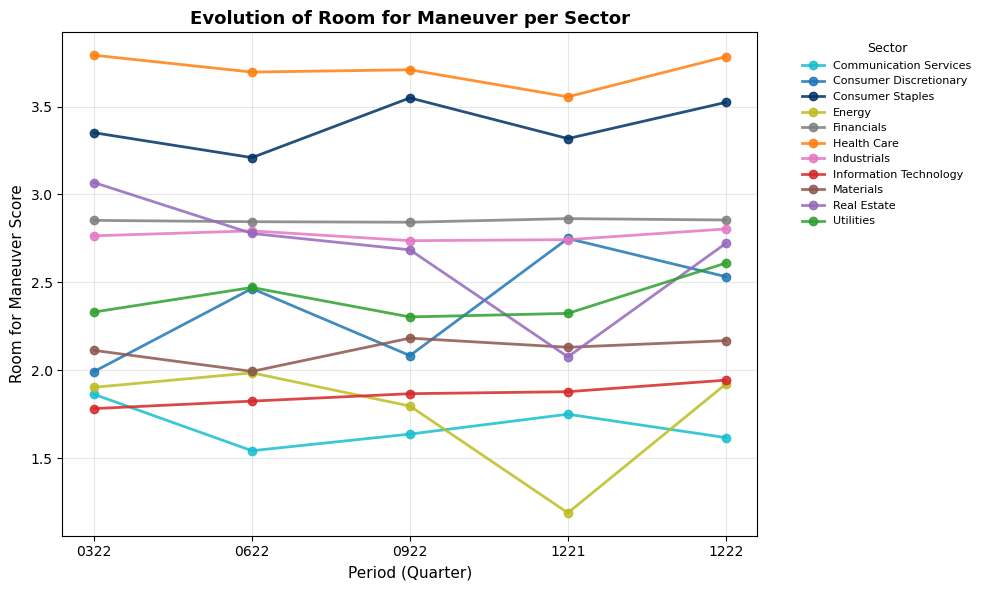

In [161]:
plot_sector_evolution(
    room_for_maneuver_score_df,
    value_col="Room_for_Maneuver_Score",
    title="Evolution of Room for Maneuver per Sector",
    ylabel="Room for Maneuver Score"
)

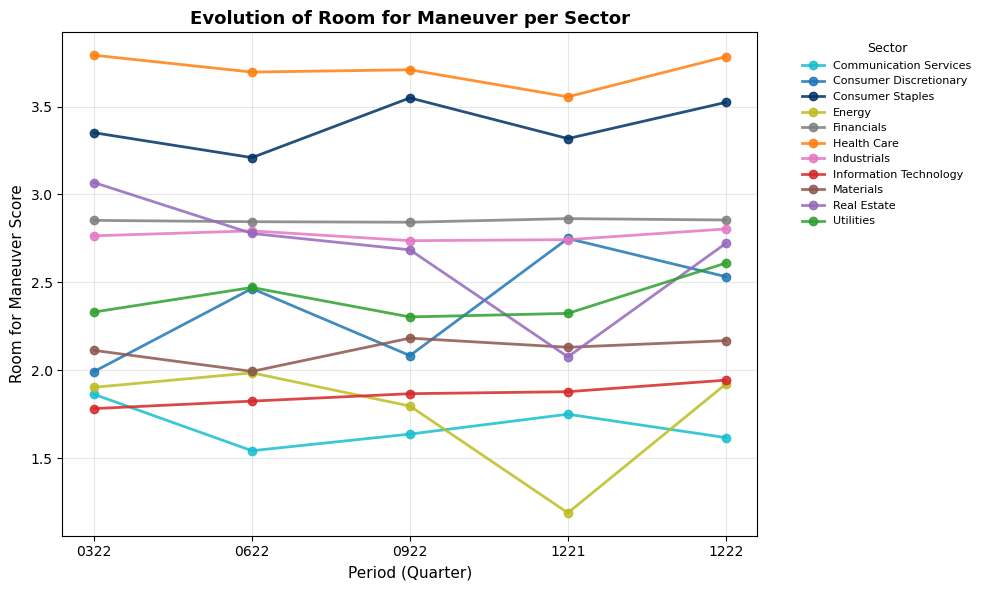

In [162]:
plot_sector_evolution(
    room_for_maneuver_score_df,
    value_col="Room_for_Maneuver_Score",
    title="Evolution of Room for Maneuver per Sector",
    ylabel="Room for Maneuver Score"
)

In [163]:
# --- knobs ---
eps = 0.02
delta_R  = 1e-3
delta_TE = 1e-8
K_dirs   = 500
NO_IMPROVE_PATIENCE = 40
ZERO_TOL = 1e-10

ECOS_OPTS = dict(abstol=1e-6, reltol=1e-6, feastol=1e-6, verbose=False)
SCS_OPTS  = dict(eps=5e-4, max_iters=5000, verbose=False, acceleration_lookback=20)
USE_SCS_FALLBACK = True


# --- utilities ---
def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg, lw.shrinkage_

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

def process_sector(sector_name, info, data, log_returns_all):
    R_clean = log_returns_all[sector_name].drop(columns=['Date']).dropna()

    w_bench = info["w_bench"].astype(float).ravel()

    w_opt   = info["w_opt"].astype(float).ravel()
    stock_labels = list(info["stock_labels"])

    # covariance for this sector
    R_clean = log_returns_all[sector_name].drop(columns=['Date']).dropna()
    Sigma_sector, _ = sigma_reg_fn(R_clean)
    Sigma_sector = nearest_psd(Sigma_sector)

    # carbon vector
    c_vec = data.loc[data['GICS Sector'] == sector_name, ['Carbon Intensity']].values.flatten().astype(float)

    # baseline / optimal reduction
    c_b   = float(w_bench @ c_vec)
    c_opt = float(w_opt   @ c_vec)
    R_star = (c_b - c_opt) / c_b

    # TE cap (2% annual)
    te_annual = 0.02
    te_var_monthly_cap = (te_annual / np.sqrt(12))**2

    N = len(w_bench)

    # -------------------------------
    # A) ε-bands
    # -------------------------------
    def eps_constraints(w):
        return [
            cp.quad_form(w - w_bench, cp.psd_wrap(Sigma_sector)) <= te_var_monthly_cap,
            cp.sum(w) == 1,
            w >= 0,
            (c_b - c_vec @ w) / c_b >= (1 - eps) * R_star
        ]

    bands = []
    for i, name in enumerate(stock_labels):
        # Max w_i
        w = cp.Variable(N)
        prob_max = cp.Problem(cp.Maximize(w[i]), eps_constraints(w))
        prob_max.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_max.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_max.solve(solver=cp.SCS, **SCS_OPTS)
        w_max = w.value[i] if w.value is not None else np.nan

        # Min w_i
        w = cp.Variable(N)
        prob_min = cp.Problem(cp.Minimize(w[i]), eps_constraints(w))
        prob_min.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_min.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_min.solve(solver=cp.SCS, **SCS_OPTS)
        w_min = w.value[i] if w.value is not None else np.nan

        # hygiene
        if (not np.isfinite(w_min)) or (w_min < ZERO_TOL): w_min = 0.0
        if (not np.isfinite(w_max)) or (w_max < ZERO_TOL): w_max = 0.0
        w_min = float(min(max(w_min, 0.0), 1.0))
        w_max = float(min(max(w_max, 0.0), 1.0))

        bands.append([name, w_min, w_max, w_max - w_min])

    bands_df = pd.DataFrame(bands, columns=["symbol", "w_min", "w_max", "bandwidth"]).sort_values("bandwidth", ascending=False)

    # quick ε-band stats
    avg_bw = float(bands_df["bandwidth"].mean())
    med_bw = float(bands_df["bandwidth"].median())
    max_bw = float(bands_df["bandwidth"].max())
    pct_wmin_zero = float((bands_df["w_min"] <= ZERO_TOL).mean()) * 100.0

    # -------------------------------
    # B) L2 lower bound
    # -------------------------------
    w = cp.Variable(N)
    v = cp.Parameter(N)

    constraints_same_obj = [
        cp.quad_form(w - w_bench, cp.psd_wrap(Sigma_sector)) <= te_var_monthly_cap + delta_TE,
        cp.sum(w) == 1,
        w >= 0,
        ((c_b - c_vec @ w) / c_b) >= R_star - delta_R,
        ((c_b - c_vec @ w) / c_b) <= R_star + delta_R
    ]
    prob_dir = cp.Problem(cp.Maximize(v @ w), constraints_same_obj)

    rng = np.random.default_rng(42)
    best_lb = 0.0
    stale = 0

    for it in range(K_dirs):
        vv = rng.standard_normal(N)
        nrm = np.linalg.norm(vv)
        if nrm == 0:
            continue
        vv /= nrm

        # max v^T w
        v.value = vv
        prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_dir.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
        cand1 = abs(float(vv @ (w.value - w_opt))) if (w.value is not None) else 0.0

        # max (-v)^T w
        v.value = -vv
        prob_dir.solve(solver=cp.ECOS, **ECOS_OPTS)
        if (w.value is None or prob_dir.status not in ("optimal", "optimal_inaccurate")) and USE_SCS_FALLBACK:
            prob_dir.solve(solver=cp.SCS, **SCS_OPTS)
        cand2 = abs(float((-vv) @ (w.value - w_opt))) if (w.value is not None) else 0.0

        new_best = max(best_lb, cand1, cand2)
        if new_best > best_lb + 1e-6:
            best_lb = new_best
            stale = 0
        else:
            stale += 1
            if stale >= NO_IMPROVE_PATIENCE:
                break

    l2_lower_bound = best_lb
    l1_turnover_upper = float(np.sqrt(N) * l2_lower_bound)

    # extra stats
    hhi_b = float(np.sum(w_bench**2))
    hhi_o = float(np.sum(w_opt**2))
    top3 = bands_df.sort_values("bandwidth", ascending=False).head(3)[["symbol","bandwidth"]]
    top3_list = [f"{r.symbol} ({r.bandwidth:.2%})" for r in top3.itertuples(index=False)]

    # -------------------------------
    # Row: pretty + raw fields
    # -------------------------------
    summary_row = {
        "Sector": sector_name,
        "Names (N)": N,
        "TE cap": "2.0%",
        "Tracking Error (bps)": f"{info['tracking_error_at_2pct']:.1f}",
        "Carbon reduction R*": f"{R_star:.1%}",
        "Carbon saved (abs)": f"{c_b - c_opt:.2f}",
        "HHI (bench → opt)": f"{hhi_b:.3f} → {hhi_o:.3f}",
        "Effective N (bench → opt)": f"{1/hhi_b:.1f} → {1/hhi_o:.1f}",
        "Support size (bench → opt)": f"{(w_bench>1e-4).sum()} → {(w_opt>1e-4).sum()}",
        "Avg / Median / Max ε-band": f"{avg_bw:.2%} / {med_bw:.2%} / {max_bw:.2%}",
        "90th pct ε-band": f"{bands_df['bandwidth'].quantile(0.9):.2%}",
        "% names at w_min=0": f"{pct_wmin_zero:.1f}%",
        "L2 lower bound (same obj)": f"{l2_lower_bound:.3f}",
        "Turnover UB (√N * L2)": f"{np.sqrt(N)*l2_lower_bound:.3f}",
        "Top flexible names": "; ".join(top3_list),
        "Most pinned name": bands_df.loc[bands_df["bandwidth"].idxmin(), "symbol"],

        # --- raw numeric fields for sorting ---
        "L2_lower_bound_same_obj": l2_lower_bound,
        "Avg_bandwidth": avg_bw,
        "Median_bandwidth": med_bw,
        "Max_bandwidth": max_bw,
        "Pct_wmin_zero": pct_wmin_zero,
    }

    return sector_name, bands_df, summary_row


In [164]:
def extract_optimal_portfolios_at_target_te(optimal_portfolios_all_te, target_te_bps=200):
    """
    Extracts the portfolio weights and carbon reduction levels closest to the target TE (bps)
    from the full carbon-TE frontier results.
    """
    optimal_portfolios_target_TE = {}

    for sector, info in optimal_portfolios_all_te.items():
        te_list = np.array(info["tracking_errors"])
        weights_list = info["weights_by_te"]

        if len(te_list) == 0:
            continue

        # find index of TE closest to target
        idx_closest = np.argmin(np.abs(te_list - target_te_bps))
        te_closest = te_list[idx_closest]
        w_opt = weights_list[idx_closest]

        optimal_portfolios_target_TE[sector] = {
            "cov_type": info["cov_type"],
            "diagnostics": info["diagnostics"],
            "w_opt": w_opt,
            "w_bench": info.get("w_bench"),
            "stock_labels": info.get("stock_labels"),
            "tracking_error_at_2pct": te_closest,
"carbon_reduction_at_2pct": info["carbon_reductions"][idx_closest]
        }

    return optimal_portfolios_target_TE


In [165]:
periods = {
    "1221": "Dec 2021",
    "0322": "Mar 2022",
    "0622": "Jun 2022",
    "0922": "Sep 2022",
    "1222": "Dec 2022"
}

all_flexibility_dfs = []
all_sector_bands = {}

for period_code, period_label in periods.items():
    print(f"\n🚀 Processing period {period_label} ({period_code})")

    # file paths
    optim_file = f"results/optimal_portfolios/optimal_portfolios_all_te_{period_code}.pkl"
    pickle_file = f"results/flexibility/sector_bands_{period_code}.pkl"
    excel_file  = f"results/flexibility/l2_bandwidth_turnover_{period_code}.xlsx"
    dataset_file = f"Data/datasets/dataset_comp_{period_code}.xlsx"
    returns_file = f"Data/log_returns/sector_log_returns_comp_{period_code}.xlsx"

    # --- load optimal frontier and extract 2% TE portfolios
    with open(optim_file, "rb") as f:
        optimal_portfolios_all_te = pickle.load(f)
    optimal_portfolios_shrink_2_TE = extract_optimal_portfolios_at_target_te(optimal_portfolios_all_te, target_te_bps=200)

    # --- use cache if available
    if os.path.exists(pickle_file) and os.path.exists(excel_file):
        print("✅ Using cached flexibility results.")
        with open(pickle_file, "rb") as f:
            sector_bands = pickle.load(f)
        sector_flexibility = pd.read_excel(excel_file)
    else:
        print("⚙️ Running fresh ε-band & L₂ optimization...")

        data = pd.read_excel(dataset_file)
        log_returns_all = pd.read_excel(returns_file, sheet_name=None)

        results = Parallel(n_jobs=-1)(
            delayed(process_sector)(s, i, data, log_returns_all)
            for s, i in optimal_portfolios_shrink_2_TE.items()
        )

        sector_bands = {s: b for s, b, _ in results}
        summary_rows = [r for _, _, r in results]
        sector_flexibility = pd.DataFrame(summary_rows).sort_values(
            ["L2_lower_bound_same_obj", "Avg_bandwidth"],
            ascending=[False, False]
        )

        # save cache
        os.makedirs("results/flexibility", exist_ok=True)
        sector_flexibility.to_excel(excel_file, index=False)
        with open(pickle_file, "wb") as f:
            pickle.dump(sector_bands, f)

    # --- add period and store
    sector_flexibility["Period"] = period_code
    all_flexibility_dfs.append(sector_flexibility)
    all_sector_bands[period_code] = sector_bands

# combine all periods
flexibility_panel = pd.concat(all_flexibility_dfs, ignore_index=True)
flexibility_panel.to_excel("results/flexibility/sector_flexibility_panel.xlsx", index=False)
print("\n✅ Saved all-period flexibility panel.")



🚀 Processing period Dec 2021 (1221)
✅ Using cached flexibility results.

🚀 Processing period Mar 2022 (0322)
✅ Using cached flexibility results.

🚀 Processing period Jun 2022 (0622)
✅ Using cached flexibility results.

🚀 Processing period Sep 2022 (0922)
✅ Using cached flexibility results.

🚀 Processing period Dec 2022 (1222)
✅ Using cached flexibility results.

✅ Saved all-period flexibility panel.


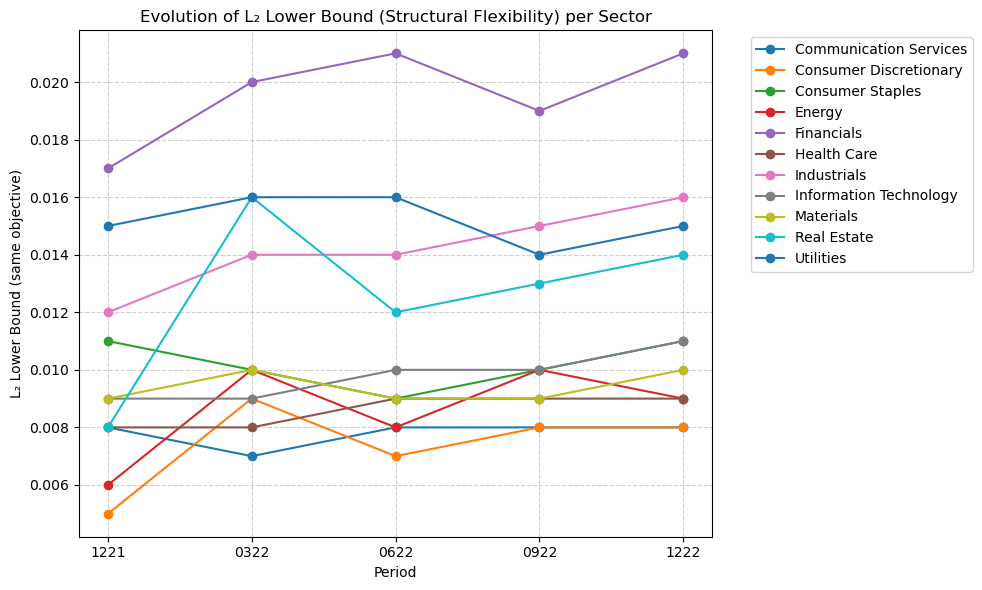

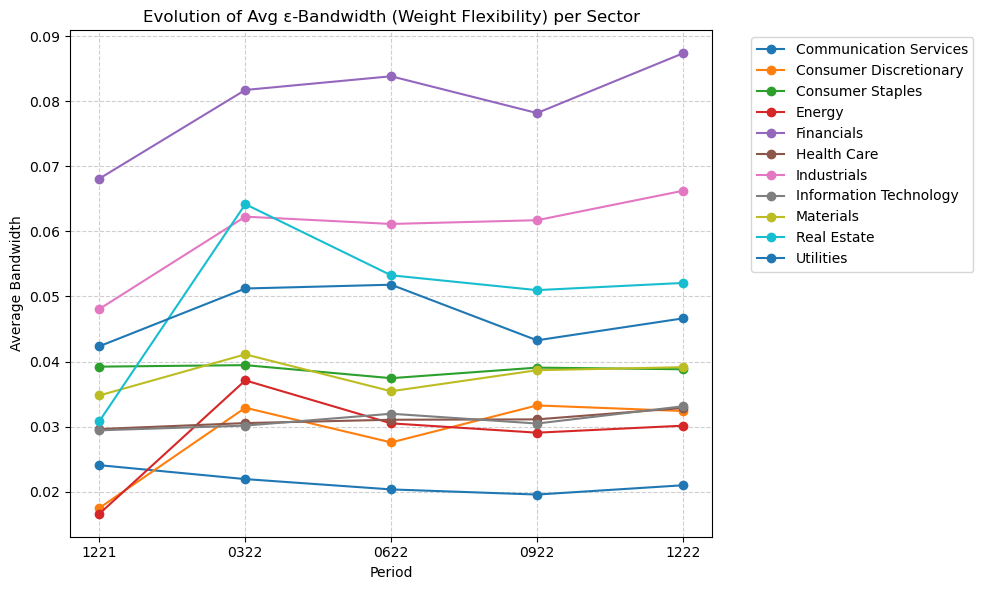

In [166]:
# Load the combined flexibility panel
flexibility_panel = pd.read_excel("results/flexibility/sector_flexibility_panel.xlsx")

period_order = ["1221", "0322", "0622", "0922", "1222"]

# Number of sectors per period
n_sectors = flexibility_panel["Sector"].nunique()
rows_per_period = len(flexibility_panel) // len(period_order)

# Reassign Period column
flexibility_panel["Period"] = np.repeat(period_order, rows_per_period)

# Clean column names
flexibility_panel.columns = flexibility_panel.columns.str.strip()

# Find likely numeric columns
cols_to_fix = [c for c in flexibility_panel.columns if "bandwidth" in c.lower() or "l2" in c.lower()]

# Convert them to numeric (coerce errors → NaN)
for col in cols_to_fix:
    flexibility_panel[col] = pd.to_numeric(flexibility_panel[col], errors="coerce")
period_order = ["1221", "0322", "0622", "0922", "1222"]
flexibility_panel["Period"] = pd.Categorical(flexibility_panel["Period"], categories=period_order, ordered=True)
flexibility_panel = flexibility_panel.sort_values(["Sector", "Period"])

plt.figure(figsize=(10,6))
for sector, grp in flexibility_panel.groupby("Sector"):
  
    plt.plot(grp["Period"], grp['L2 lower bound (same obj)'], marker="o", label=sector)

plt.title("Evolution of L₂ Lower Bound (Structural Flexibility) per Sector")
plt.ylabel("L₂ Lower Bound (same objective)")
plt.xlabel("Period")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
for sector, grp in flexibility_panel.groupby("Sector"):
    plt.plot(grp["Period"], grp["Avg_bandwidth"], marker="o", label=sector)

plt.title("Evolution of Avg ε-Bandwidth (Weight Flexibility) per Sector")
plt.ylabel("Average Bandwidth")
plt.xlabel("Period")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [167]:
def build_pure_flexibility_score(df):
    df = df.copy()

    def norm(x):
        x = pd.to_numeric(x, errors='coerce')
        return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

    df["n_L2"]    = norm(df["L2_lower_bound_same_obj"])
    df["n_AvgBW"] = norm(df["Avg_bandwidth"])

    df["Flexibility_Score"] = (
        0.5 * df["n_L2"] +
        0.5 * df["n_AvgBW"]
    )

    return df



Evolution across sectors - Flexibility score: 

In [168]:
# 4 Apply score computation *within each period* 

scored_panel = (
    flexibility_panel
    .groupby("Period", group_keys=False)
    .apply(build_pure_flexibility_score)
)

flexibility_score_df = scored_panel[['Sector', 'Period', 'Flexibility_Score']]


/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_37224/3435684561.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Period", group_keys=False)
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_37224/3435684561.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(build_pure_flexibility_score)


Evolution across sectors - Robustness score: 

Processing period 1221 ...
Processing period 0322 ...
Processing period 0622 ...
Processing period 0922 ...
Processing period 1222 ...


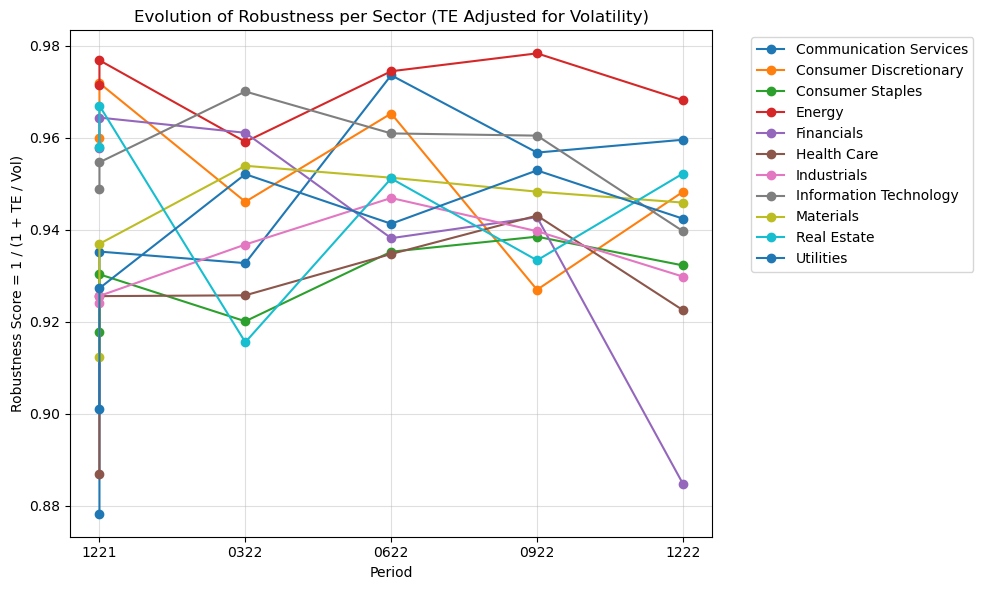

In [169]:
# Parameters
TE_TARGET_ANNUAL = 0.02
TE_TARGET_Q = TE_TARGET_ANNUAL / np.sqrt(4)

# Files for all testing periods
periods = ["1221", "0322", "0622", "0922", "1222"]

records = []

for p in periods:
    print(f"Processing period {p} ...")

    # --- Load TE file ---
    te_path = f"Data/te-testing-results/te_{p}.xlsx"
    te_df = pd.read_excel(te_path).rename(columns={"Unnamed: 0": "Sector"})
    te_df["TE_quarterly"] = te_df["Annualised_TE"] / np.sqrt(4)

    # --- Load realized returns ---
    ret_path = f"Data/te-testing-results/quarterly_ret_{p}.xlsx"
    ret_df = pd.read_excel(ret_path)

    # --- Merge TE and returns ---
    merged = pd.merge(te_df, ret_df, on="Sector", how="inner")

    # --- Estimate realized volatility for each sector benchmark ---
    # Assuming you have daily benchmark returns in ret_df
    # (if not, replace this with a precomputed volatility per sector per period)
    if "Volatility_Q" not in merged.columns:
        print("⚠️ No 'Volatility_Q' column found — estimating from realized benchmark returns.")
        merged["Volatility_Q"] = np.nan  # placeholder

    # --- Compute robustness ratio (TE / Volatility) ---
    merged["Robustness_Ratio"] = merged["TE_quarterly"] / merged["Volatility_Q"]

    # --- Convert to intuitive robustness score (higher = more robust) ---
    merged["Robustness_Score"] = 1 / (1 + merged["Robustness_Ratio"])

    # Add identifier
    merged["Period"] = p

    # Keep relevant columns
    records.append(merged[[
        "Sector",
        "Period",
        "TE_quarterly",
        "Volatility_Q",
        "Robustness_Ratio",
        "Robustness_Score"
    ]])

# --- Combine all periods ---
robust_df = pd.concat(records, ignore_index=True)

# --- Aggregate per sector over time ---
robust_summary = robust_df.groupby("Sector").agg({
    "TE_quarterly": "mean",
    "Volatility_Q": "mean",
    "Robustness_Ratio": "mean",
    "Robustness_Score": "mean"
}).reset_index()

# Rename for clarity
robust_summary = robust_summary.rename(columns={
    "TE_quarterly": "Avg_Realized_TE",
    "Volatility_Q": "Avg_Sector_Vol",
    "Robustness_Ratio": "Avg_Ratio_TE_Vol",
    "Robustness_Score": "Avg_Robustness_Score"
})

# --- Save for plotting ---
robust_df.to_excel("Data/te-testing-results/robustness_panel.xlsx", index=False)
robust_summary.to_excel("Data/te-testing-results/robustness_summary.xlsx", index=False)

# Define period order
period_order = ["1221", "0322", "0622", "0922", "1222"]

# Make Period categorical for ordered plotting
robust_df["Period"] = pd.Categorical(robust_df["Period"], categories=period_order, ordered=True)

# Sort for plotting
robust_df = robust_df.sort_values(["Sector", "Period"])

plt.figure(figsize=(10, 6))

for sector, grp in robust_df.groupby("Sector"):
    plt.plot(grp["Period"], grp["Robustness_Score"], marker="o", label=sector)

plt.title("Evolution of Robustness per Sector (TE Adjusted for Volatility)")
plt.ylabel("Robustness Score = 1 / (1 + TE / Vol)")
plt.xlabel("Period")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [170]:
robustness_score_df = robust_df[['Sector', 'Period', 'Robustness_Score']]

In [171]:

# ---------- helpers ----------
def l1_turnover_pct(w_from, w_to):
    """One-way turnover (% of portfolio) to go from w_from → w_to."""
    return 0.5 * float(np.abs(w_to - w_from).sum()) * 100.0

def cosine_similarity(a, b):
    a = np.asarray(a); b = np.asarray(b)
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def realized_te_annual(w, w_b, Sigma):
    """Annualized TE in decimal (e.g., 0.02 == 2%)."""
    diff = (w - w_b)
    te_m = float(diff.T @ Sigma @ diff)
    te_a = np.sqrt(te_m) * np.sqrt(12.0)
    return te_a

def carbon_reduction_pct(w, w_b, c_vec):
    """% reduction relative to benchmark carbon; returns in percent units."""
    cb = float(np.dot(w_b, c_vec))
    co = float(np.dot(w,   c_vec))
    if cb == 0:
        return np.nan
    return (cb - co) / cb * 100.0

def nanpercentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.percentile(x, q)) if x.size else np.nan

def sensitivity_kpis_from_trials(
    w_trials,             # (n_trials, N) weights from perturbations (optimized each trial)
    te_trials_annual,     # (n_trials,) TE in decimal for each trial (annualized)
    R_clean,              # baseline returns (DataFrame without Date)
    w_bench,              # benchmark weights (N,)
    c_vec,                # carbon intensity per name (N,)
    Sigma_fn,             # function R_clean -> Sigma
    te_cap=0.02,          # baseline TE cap (annual)
    w_opt0=None           # baseline optimized weights; if None, will solve
):
    """
    Returns a dict with the KPIs + the raw per-trial series (for plots).
    """
    # Baseline (with clean Sigma)
    w_opt0, te0, Rstar0, Sigma0 = baseline_diagnostics(R_clean, w_bench, c_vec, Sigma_fn, te_cap, w_opt0)

    # Per-trial measures vs baseline optimized portfolio
    turnovers = []
    cosines   = []
    carbon_losses_pp = []   # baseline reduction minus trial reduction (pp)
    te_drifts_bps    = []   # |TE_trial - TE_baseline| in bps

    for w_t, te_t in zip(w_trials, te_trials_annual):
        if w_t is None or not np.all(np.isfinite(w_t)) or (te_t is None) or not np.isfinite(te_t):
            turnovers.append(np.nan); cosines.append(np.nan)
            carbon_losses_pp.append(np.nan); te_drifts_bps.append(np.nan)
            continue

        # Turnover and Cosine vs baseline optimized
        turnovers.append(l1_turnover_pct(w_opt0, w_t))
        cosines.append(cosine_similarity(w_opt0, w_t))

        # Carbon reduction loss (pp): max(0, baseline_reduction - trial_reduction)
        Rstar_t = carbon_reduction_pct(w_t, w_bench, c_vec)   # in %
        carbon_losses_pp.append(max(0.0, Rstar0 - Rstar_t))

        # TE drift (bps) relative to baseline TE
        te_drifts_bps.append(abs(te_t - te0) * 10000.0)

    # Aggregate KPIs
    kpis = {
        "Median_Turnover_pct":        nanpercentile(turnovers, 50),
        "Median_Cosine":              nanpercentile(cosines, 50),
        "P95_CarbonLoss_pp":          nanpercentile(carbon_losses_pp, 95),
        "P95_TE_Drift_bps":           nanpercentile(te_drifts_bps, 95),
        # keep handy for plots/debug
        "series": {
            "turnover_pct": np.array(turnovers, dtype=float),
            "cosine":       np.array(cosines, dtype=float),
            "carbon_loss_pp": np.array(carbon_losses_pp, dtype=float),
            "te_drift_bps":   np.array(te_drifts_bps, dtype=float),
            "baseline": {
                "w_opt0": w_opt0,
                "te0_annual": te0,
                "Rstar0_pct": Rstar0
            }
        }
    }
    return kpis

# ---------- baseline (can reuse your precomputed dict) ----------
def baseline_diagnostics(R_clean, w_bench, c_vec, Sigma_fn, te_cap=0.02, w_opt=None):
    """
    Returns (w_opt0, te0_annual, Rstar0, Sigma0)
    - If w_opt is None, solves the baseline optimization; otherwise uses provided w_opt.
    """
    # Sigma at baseline (on clean returns)
    Sigma0 = Sigma_fn(R_clean)

    if w_opt is None:
        # Solve baseline optim (same as your optimize_sector but minimal)
        N = len(w_bench)
        w = cp.Variable(N)
        te_cap_var_monthly = (te_cap / np.sqrt(12))**2
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma0))
        obj = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        cons = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(obj, cons)
        prob.solve(solver=cp.ECOS, verbose=False)
        if prob.status not in ("optimal","optimal_inaccurate") or w.value is None:
            raise RuntimeError(f"Baseline optimization failed: {prob.status}")
        w_opt0 = w.value
    else:
        w_opt0 = np.asarray(w_opt, dtype=float)

    te0 = realized_te_annual(w_opt0, w_bench, Sigma0)              # decimal, e.g. 0.02
    Rstar0 = carbon_reduction_pct(w_opt0, w_bench, c_vec)          # percent
    return w_opt0, te0, Rstar0, Sigma0

In [172]:

# === UTILITIES ===

def sigma_raw_fn(R_clean):
    return R_clean.cov()

def sigma_reg_fn(R_clean):
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_
    lambda_I = 1e-5
    return Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])

def simulate_parametric_noise(mu, Sigma, T, n_trials):
    return [np.random.multivariate_normal(mu, Sigma, T) for _ in range(n_trials)]

def bootstrap_returns(R_clean_np, n_trials):
    T = R_clean_np.shape[0]
    return [R_clean_np[np.random.choice(T, T, replace=True)] for _ in range(n_trials)]

def compute_perturbed_weights_from_samples(R_samples, w_bench, c_vec, Sigma_fn, te_cap=0.03):
    weights, tracking_errors = [], []
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    N = len(w_bench)

    for R_perturbed in R_samples:
        Sigma = Sigma_fn(pd.DataFrame(R_perturbed))
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_bench
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)

def compute_perturbed_weights(
    R_clean,
    w_bench,
    c_vec,
    Sigma_fn,
    te_cap=0.03,
    n_trials=100,
    noise_std=0.01,
    noise_type="multiplicative"  # or "additive"
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    weights = []
    tracking_errors = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)

        if noise_type == "multiplicative":
            R_perturbed = R_clean + R_clean.multiply(noise)
        elif noise_type == "additive":
            R_perturbed = R_clean + noise
        else:
            raise ValueError("noise_type must be 'multiplicative' or 'additive'")

        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_bench, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            weights.append(w.value)
            diff = w.value - w_bench
            te_real = np.sqrt(diff.T @ Sigma @ diff) * np.sqrt(12)
            tracking_errors.append(te_real)
        else:
            weights.append(np.full(N, np.nan))
            tracking_errors.append(np.nan)

    return np.array(weights), np.array(tracking_errors)


def compute_hhi(weights):
    return np.sum(np.square(weights))

def check_total_variability(R_clean, sector_name):
    sdev = R_clean.std(axis=0)
    annualised_sdev = sdev * (12**0.5)
    return annualised_sdev

In [173]:
# --- parameters ---
periods = ["1221", "0322", "0622", "0922", "1222"]
n_trials = 200

# --- containers ---
all_sensitivity = []

for period_tag in periods:
    print(f"\n🚀 Running sensitivity analysis for {period_tag} …")

    # define file paths
    data_file = f"data/datasets/dataset_comp_{period_tag}.xlsx"
    returns_file = f"Data/log_returns/sector_log_returns_comp_{period_tag}.xlsx"
    optim_file = f"results/optimal_portfolios/optimal_portfolios_all_te_{period_tag}.pkl"
    out_dir = f"results/sensitivity"
    out_pickle = f"{out_dir}/sensitivity_kpis_{period_tag}.pkl"
    out_excel = f"{out_dir}/sensitivity_kpis_{period_tag}.xlsx"

    # -------------------------------
    # Load optimization frontier
    # -------------------------------
    with open(optim_file, "rb") as f:
        optimal_portfolios_all_te = pickle.load(f)

    optimal_portfolios_shrink_2_TE = extract_optimal_portfolios_at_target_te(
        optimal_portfolios_all_te, target_te_bps=200
    )

    os.makedirs(out_dir, exist_ok=True)

    # -------------------------------
    # Check cache
    # -------------------------------
    if os.path.exists(out_pickle) and os.path.exists(out_excel):
        print(f"✅ Using cached results for {period_tag}.")
        with open(out_pickle, "rb") as f:
            sensitivity_results = pickle.load(f)
        tmp = pd.read_excel(out_excel)
        tmp["Period"] = period_tag
        all_sensitivity.append(tmp)
        continue  # skip recomputation

    # -------------------------------
    # Run new computation
    # -------------------------------
    print(f"⚙️ Computing fresh sensitivity KPIs for {period_tag}…")

    data = pd.read_excel(data_file)
    sensitivity_results = {}

    for sector_name in data["GICS Sector"].unique():
        print(f"[{sector_name}] computing sensitivity KPIs…")

        # Load returns for this sector
        R = pd.read_excel(returns_file, sheet_name=sector_name)
        R_clean = R.drop(columns=["Date"]).dropna()

        # Benchmark weights + carbon intensity
        sector = data[data["GICS Sector"] == sector_name]
        w_bench = sector["weight_in_sector"].values
        c_vec = sector["Carbon Intensity"].values

        # Baseline optimized weights (already precomputed)
        w_opt0 = optimal_portfolios_shrink_2_TE[sector_name]["w_opt"]

        # === Perturbations ===
        w_trials, te_trials = compute_perturbed_weights(
            R_clean,
            w_bench,
            c_vec,
            sigma_reg_fn,
            te_cap=0.02,  # annual TE cap
            n_trials=n_trials,
            noise_std=0.2,
            noise_type="multiplicative",
        )

        # === Compute KPIs ===
        kpis = sensitivity_kpis_from_trials(
            w_trials=w_trials,
            te_trials_annual=te_trials,
            R_clean=R_clean,
            w_bench=w_bench,
            c_vec=c_vec,
            Sigma_fn=sigma_reg_fn,
            te_cap=0.02,
            w_opt0=w_opt0,
        )

        sensitivity_results[sector_name] = {
            "Median_Turnover_pct": kpis["Median_Turnover_pct"],
            "Median_Cosine": kpis["Median_Cosine"],
            "P95_CarbonLoss_pp": kpis["P95_CarbonLoss_pp"],
            "P95_TE_Drift_bps": kpis["P95_TE_Drift_bps"],
        }

    # -------------------------------
    # Save new results
    # -------------------------------
    tmp = pd.DataFrame(sensitivity_results).T.reset_index()
    tmp.rename(columns={"index": "Sector"}, inplace=True)
    tmp["Period"] = period_tag

    with open(out_pickle, "wb") as f:
        pickle.dump(sensitivity_results, f)
    tmp.to_excel(out_excel, index=False)

    print(f"✅ Saved results for {period_tag} to {out_pickle}")

    all_sensitivity.append(tmp)

# -------------------------------
# Combine all periods
# -------------------------------
panel_df = pd.concat(all_sensitivity, ignore_index=True)
panel_df.to_excel("results/sensitivity_kpis_panel.xlsx", index=False)
print("\n✅ All periods processed and saved to results/sensitivity_kpis_panel.xlsx")



🚀 Running sensitivity analysis for 1221 …
✅ Using cached results for 1221.

🚀 Running sensitivity analysis for 0322 …
✅ Using cached results for 0322.

🚀 Running sensitivity analysis for 0622 …
✅ Using cached results for 0622.

🚀 Running sensitivity analysis for 0922 …
✅ Using cached results for 0922.

🚀 Running sensitivity analysis for 1222 …
✅ Using cached results for 1222.

✅ All periods processed and saved to results/sensitivity_kpis_panel.xlsx


In [174]:
vol_df

,Sector,Sector Volatility
0,Consumer Discretionary,0.231954
1,Health Care,0.154516
2,Utilities,0.191346
3,Information Technology,0.243412
4,Real Estate,0.214494
5,Materials,0.228223
6,Industrials,0.208522
7,Financials,0.209617
8,Energy,0.324601
9,Communication Services,0.219821


In [175]:
# Define all periods
periods = ["1221", "0322", "0622", "0922", "1222"]

all_vols = []

for p in periods:
    print(f"📊 Processing volatility for period {p} ...")
    
    # --- Load data ---
    optim_path = f"results/optimal_portfolios/optimal_portfolios_all_te_{p}.pkl"
    returns_path = f"data/log_returns/sector_log_returns_comp_{p}.xlsx"
    
    if not os.path.exists(optim_path) or not os.path.exists(returns_path):
        print(f"⚠️ Missing data for {p}, skipping.")
        continue
    
    with open(optim_path, "rb") as file:
        optimal_data = pickle.load(file)
    
    # --- Compute volatility per sector ---
    for sector_name in optimal_data.keys():
        try:
            # Load sector returns
            R = pd.read_excel(returns_path, sheet_name=sector_name)
            R_clean = R.drop(columns=['Date']).dropna()
            
            # Benchmark weights (last period or stored)
            w_b = optimal_data[sector_name]["w_bench"]
            
            # Compute benchmark portfolio returns
            r_bench = (R_clean * w_b).sum(axis=1)
            
            # Annualized volatility (using monthly returns)
            vol_annual = np.std(r_bench) * np.sqrt(12)
            
            all_vols.append({
                "Sector": sector_name,
                "Period": p,
                "Benchmark_Volatility": vol_annual
            })
        except Exception as e:
            print(f"⚠️ Error for {sector_name} ({p}): {e}")

# --- Combine results ---
vol_df = pd.DataFrame(all_vols)
vol_df = vol_df.sort_values(["Sector", "Period"])
vol_df.to_excel("results/benchmark_volatility_by_period.xlsx", index=False)

print("✅ Saved benchmark volatility by sector and period.")


📊 Processing volatility for period 1221 ...
📊 Processing volatility for period 0322 ...
📊 Processing volatility for period 0622 ...
📊 Processing volatility for period 0922 ...
📊 Processing volatility for period 1222 ...
✅ Saved benchmark volatility by sector and period.


✅ Saved sensitivity scores to results/sensitivity_scores_by_period.xlsx


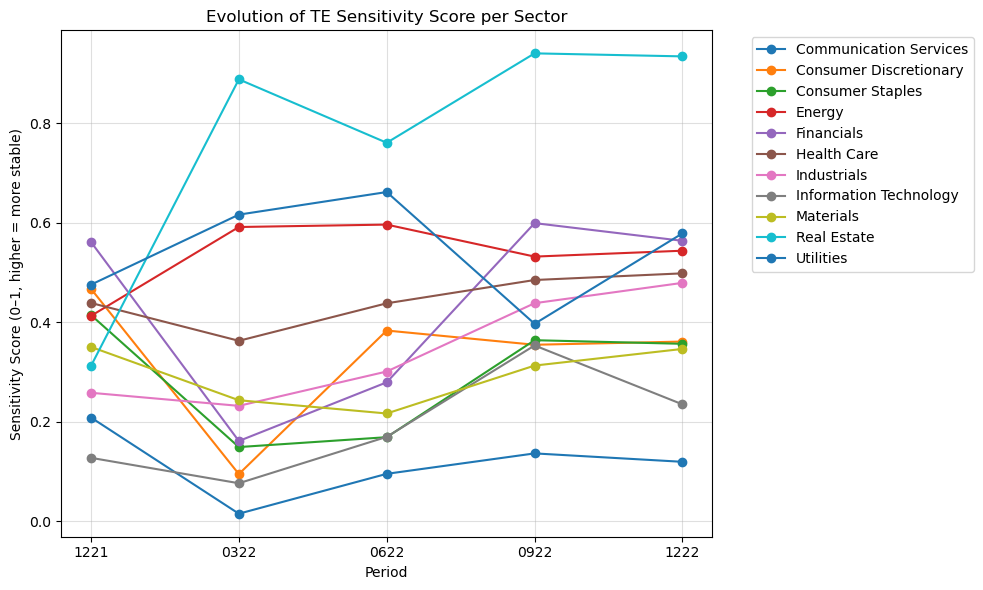

In [176]:
# --- helper ---
def minmax_norm(x):
    x = np.asarray(x, float)
    if np.nanmax(x) == np.nanmin(x):
        return np.zeros_like(x)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

# --- load data ---
sens_panel = pd.read_excel("results/sensitivity_kpis_panel.xlsx")   # must include Sector, Period
sens_panel["Period"] = sens_panel["Period"].astype(str).str.zfill(4)

df = sens_panel.copy()

# --- compute composition sensitivity (no volatility adjustment) ---
df["Turnover_norm"] = minmax_norm(df["Median_Turnover_pct"])
df["Cosine_norm"]   = minmax_norm(1 - df["Median_Cosine"])

df["Composition_Sensitivity"] = 0.5 * (df["Turnover_norm"] + df["Cosine_norm"])

# --- outcome sensitivity ---
df["Outcome_Sensitivity"] = 0.5 * (
    minmax_norm(df["P95_CarbonLoss_pp"]) +
    minmax_norm(df["P95_TE_Drift_bps"])
)

# --- overall sensitivity score ---
df["Sensitivity_Score"] = 0.5 * (
    minmax_norm(df["Composition_Sensitivity"]) +
    minmax_norm(df["Outcome_Sensitivity"])
)

# --- save and plot ---
df.to_excel("results/sensitivity_scores_by_period.xlsx", index=False)
print("✅ Saved sensitivity scores to results/sensitivity_scores_by_period.xlsx")

plt.figure(figsize=(10,6))
for sector, grp in df.groupby("Sector"):
    plt.plot(grp["Period"], grp["Sensitivity_Score"], marker="o", label=sector)

plt.title("Evolution of TE Sensitivity Score per Sector")
plt.ylabel("Sensitivity Score (0–1, higher = more stable)")
plt.xlabel("Period")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [177]:
sensitivity_score_df = df[['Sector', 'Period', 'Sensitivity_Score']]
 

In [178]:
averaged_room_for_maneuver_score_df = room_for_maneuver_score_df.groupby('Sector')['Room_for_Maneuver_Score'].mean()

averaged_room_for_maneuver_score_df = (
    (averaged_room_for_maneuver_score_df - averaged_room_for_maneuver_score_df.min()) /
    (averaged_room_for_maneuver_score_df.max() - averaged_room_for_maneuver_score_df.min())
)


averaged_flexibility_score_df = flexibility_score_df.groupby('Sector')['Flexibility_Score'].mean()

# --- Average Flexibility Score across time periods ---
averaged_flexibility_score_df = (
    flexibility_score_df
    .groupby('Sector', as_index=False)['Flexibility_Score']
    .mean()
    .rename(columns={'Flexibility_Score': 'Flexibility_Score_mean'})
)

# --- Normalize to 0–1 range for comparability ---
min_val = averaged_flexibility_score_df['Flexibility_Score_mean'].min()
max_val = averaged_flexibility_score_df['Flexibility_Score_mean'].max()

averaged_flexibility_score_df['Flexibility_Score'] = (
    (averaged_flexibility_score_df['Flexibility_Score_mean'] - min_val) /
    (max_val - min_val)
)



averaged_sensitivity_score_df = sensitivity_score_df.groupby('Sector')['Sensitivity_Score'].mean()

# --- Average Flexibility Score across time periods ---
averaged_sensitivity_score_df = (
    sensitivity_score_df
    .groupby('Sector', as_index=False)['Sensitivity_Score']
    .mean()
    .rename(columns={'Sensitivity_Score': 'Sensitivity_Score_mean'})
)

# --- Normalize to 0–1 range for comparability ---
min_val = averaged_sensitivity_score_df['Sensitivity_Score_mean'].min()
max_val = averaged_sensitivity_score_df['Sensitivity_Score_mean'].max()

averaged_sensitivity_score_df['Sensitivity_Score'] = (
    (averaged_sensitivity_score_df['Sensitivity_Score_mean'] - min_val) /
    (max_val - min_val)
)

averaged_robustness_score_df = robustness_score_df.groupby('Sector')['Robustness_Score'].mean()

In [179]:
# --- Step 1: merge all averaged sector scores ---
combined_scores = (
    averaged_room_for_maneuver_score_df.reset_index()
    .merge(averaged_flexibility_score_df.reset_index()[['Sector', 'Flexibility_Score']], on="Sector", how="outer")
    .merge(averaged_sensitivity_score_df.reset_index(), on="Sector", how="outer")
    .merge(averaged_robustness_score_df.reset_index(), on="Sector", how="outer")
)


# --- Step 2: rename for readability ---
combined_scores = combined_scores.rename(columns={
    "Room_for_Maneuver_Score":"Room for Maneuver",
    "Flexibility_Score": "Flexibility",
    "Sensitivity_Score": "Sensitivity",
    "Robustness_Score": "Robustness"
})

# --- Step 3: handle missing values ---
combined_scores = combined_scores.fillna(0)

# --- Step 4: invert Sensitivity (bad → good) ---
# normalize first (0–1) if not already
def minmax_norm(x):
    x = (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
    return x

combined_scores["Sensitivity_inverted"] = 1 - minmax_norm(combined_scores["Sensitivity"])

# --- Step 5: compute composite score ---
combined_scores["Composite_Score"] = (
    0.25 * combined_scores["Room for Maneuver"] +
    0.25 * combined_scores["Flexibility"] +
    0.25 * combined_scores["Sensitivity_inverted"] +
    0.25 * combined_scores["Robustness"]
)

# --- Step 6: save results ---
combined_scores.to_excel("results/combined_sector_scores.xlsx", index=False)



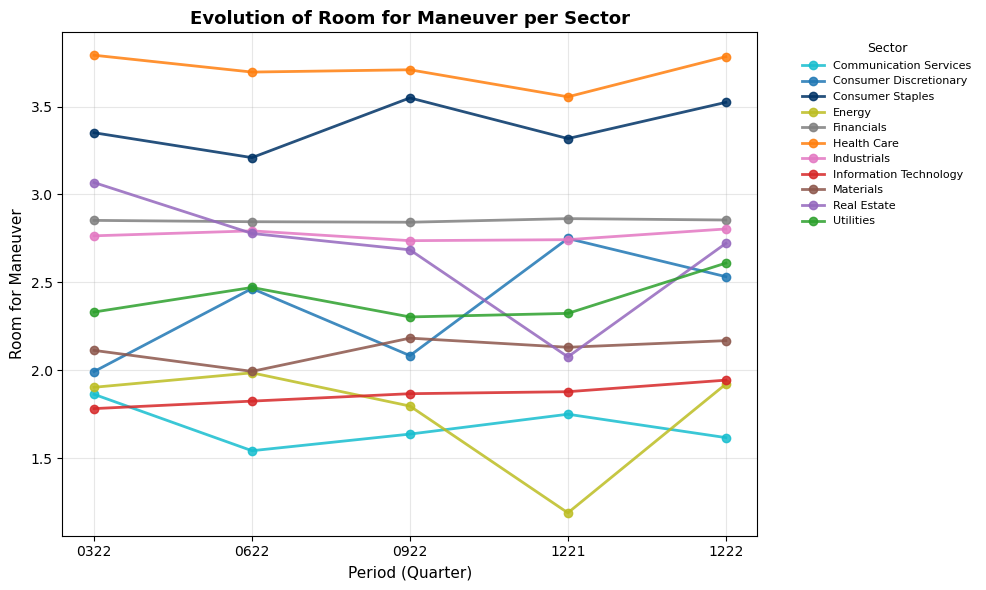

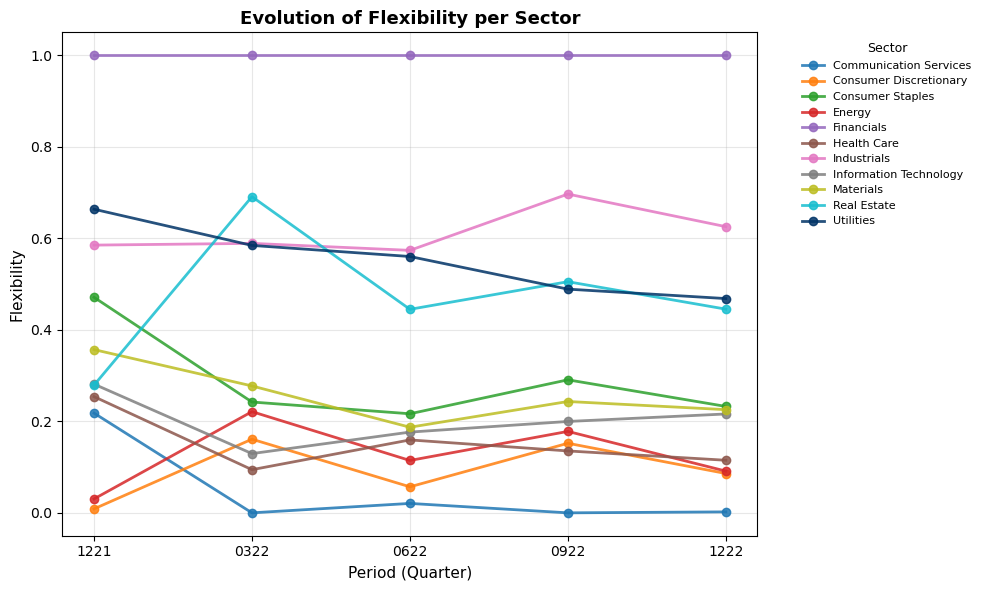

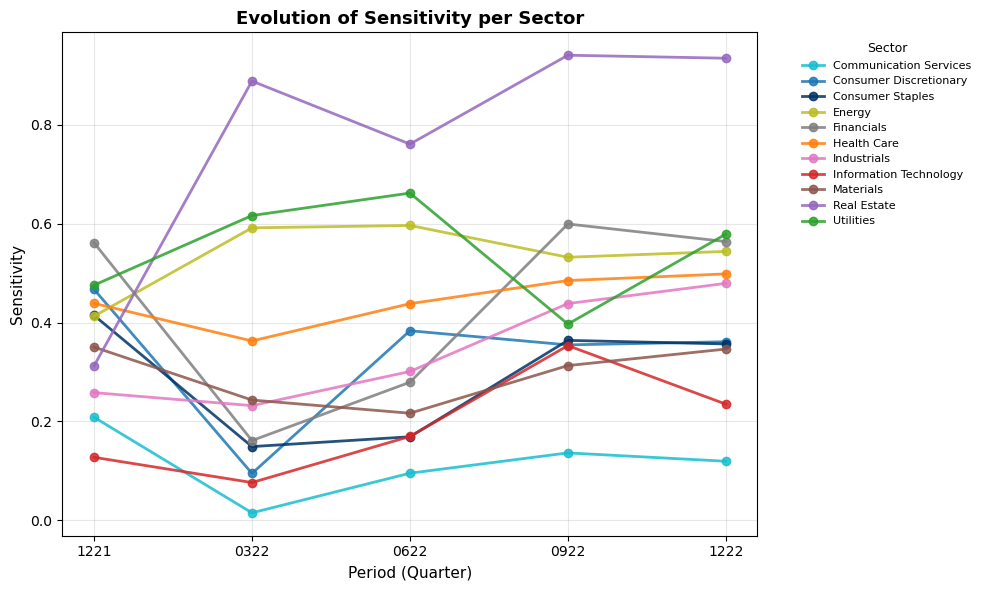

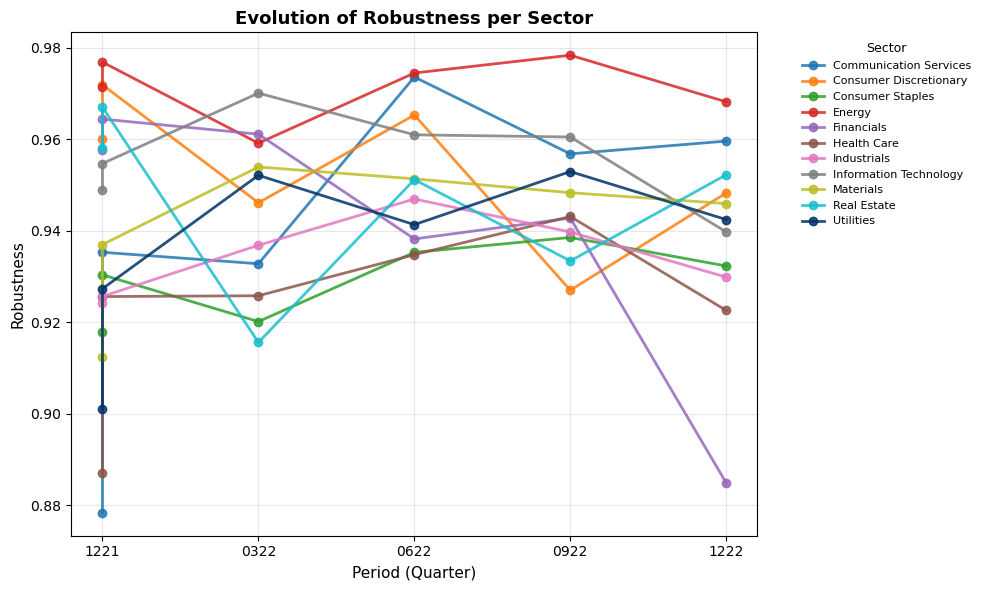

In [180]:
for score, df in [('Room for Maneuver', room_for_maneuver_score_df), 
                  ('Flexibility', flexibility_score_df),
                  ('Sensitivity', sensitivity_score_df), 
                  ('Robustness', robustness_score_df)]:

    plot_sector_evolution(
        df,
        value_col=f"{score.replace(" ", "_")}_Score",
        title=f"Evolution of {score} per Sector",
        ylabel=f"{score}"
    )

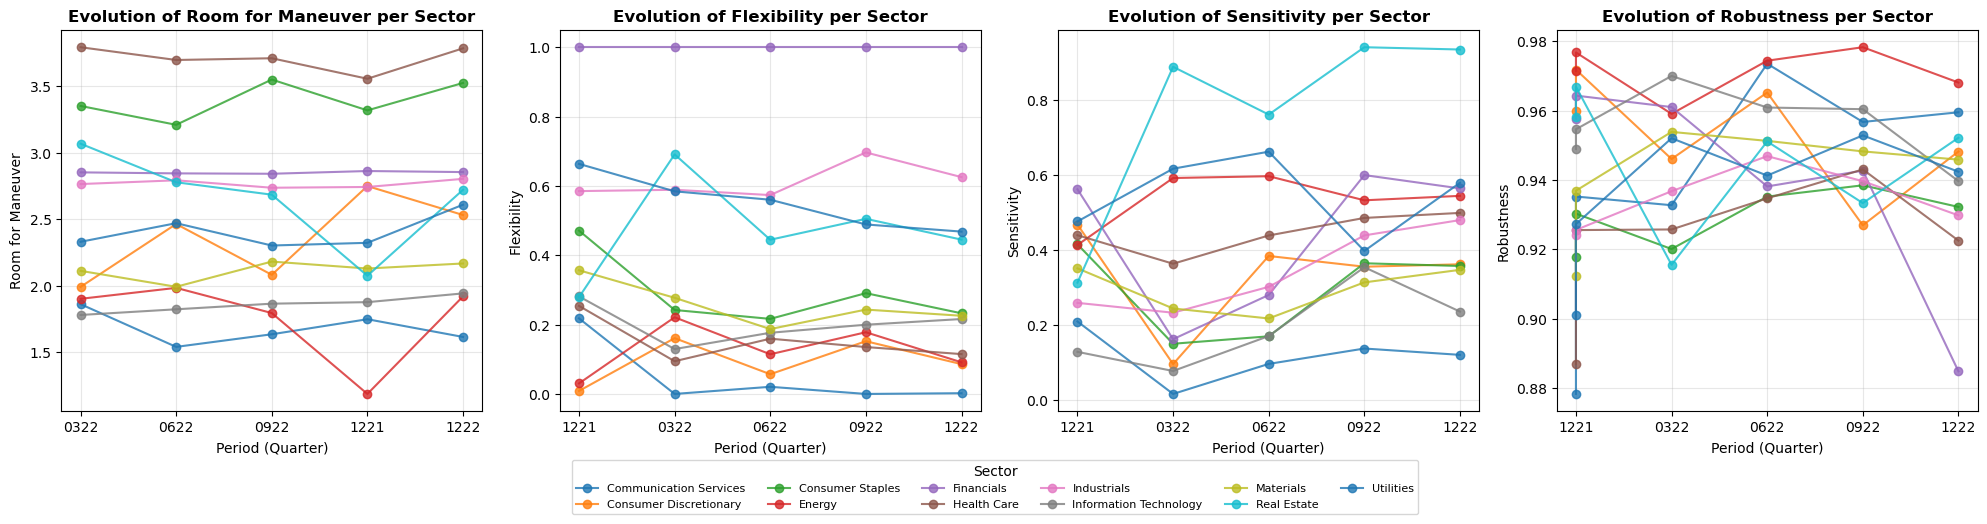

In [181]:
def plot_sector_evolution(df, value_col, title, ylabel, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    for sector, grp in df.groupby("Sector"):
        ax.plot(grp["Period"], grp[value_col], marker="o", label=sector, alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Period (Quarter)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

    # ❌ Remove the legend here
    # ax.legend(fontsize=6, loc="best")

    if ax is None:
        plt.tight_layout()
        plt.show()


# --- Define your scores and dataframes ---
score_dfs = [
    ('Room for Maneuver', room_for_maneuver_score_df),
    ('Flexibility', flexibility_score_df),
    ('Sensitivity', sensitivity_score_df),
    ('Robustness', robustness_score_df),
]

# --- Create 1x4 grid of subplots ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

# --- Loop over subplots ---
for ax, (score, df) in zip(axes, score_dfs):
    plot_sector_evolution(
        df,
        value_col=f"{score.replace(' ', '_')}_Score",
        title=f"Evolution of {score} per Sector",
        ylabel=score,
        ax=ax
    )

# --- Create one shared legend ---
# Take handles & labels from the first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",          # 👈 place below all plots
    bbox_to_anchor=(0.5, -0.05), # move further below
    ncol=6,                      # number of columns in legend
    fontsize=8,
    title="Sector"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for legend
plt.show()


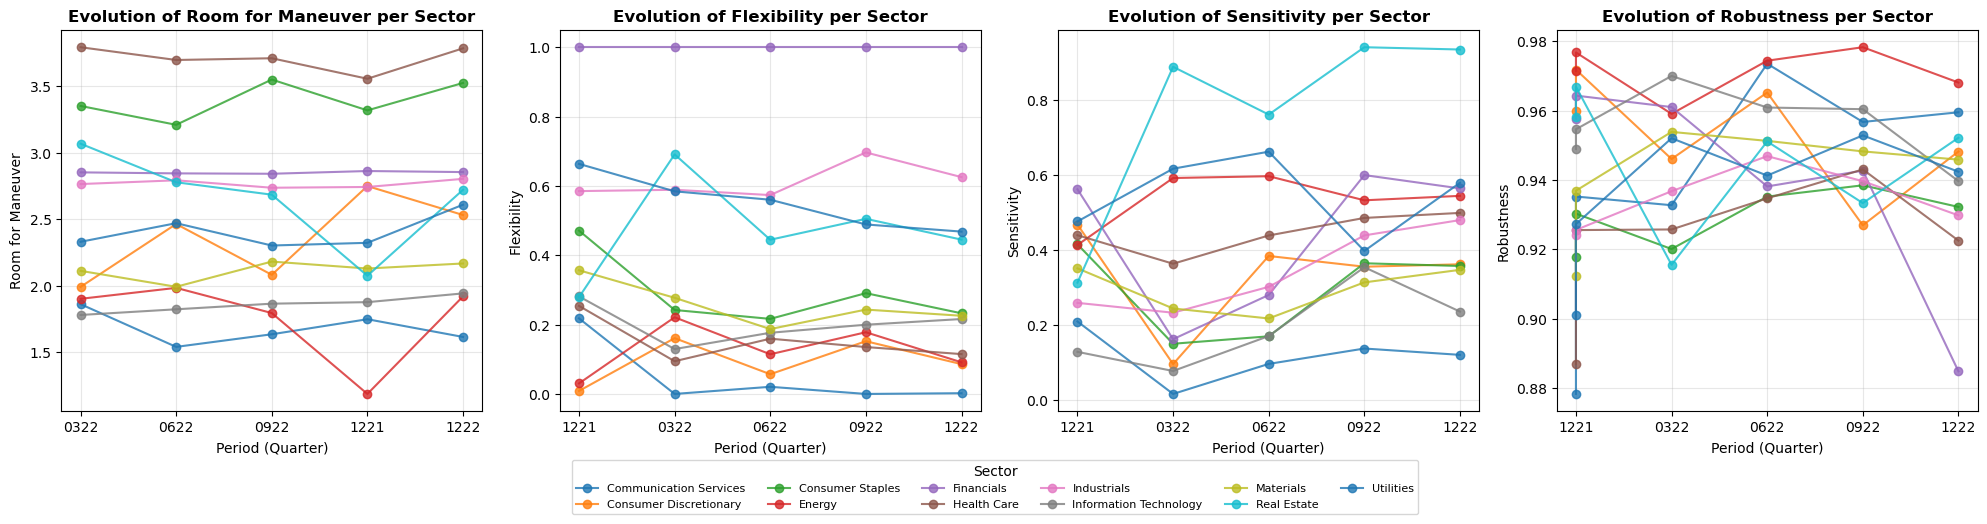

In [182]:
def plot_sector_evolution(df, value_col, title, ylabel, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    for sector, grp in df.groupby("Sector"):
        ax.plot(grp["Period"], grp[value_col], marker="o", label=sector, alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Period (Quarter)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

    # ❌ Remove the legend here
    # ax.legend(fontsize=6, loc="best")

    if ax is None:
        plt.tight_layout()
        plt.show()


# --- Define your scores and dataframes ---
score_dfs = [
    ('Room for Maneuver', room_for_maneuver_score_df),
    ('Flexibility', flexibility_score_df),
    ('Sensitivity', sensitivity_score_df),
    ('Robustness', robustness_score_df),
]

# --- Create 1x4 grid of subplots ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

# --- Loop over subplots ---
for ax, (score, df) in zip(axes, score_dfs):
    plot_sector_evolution(
        df,
        value_col=f"{score.replace(' ', '_')}_Score",
        title=f"Evolution of {score} per Sector",
        ylabel=score,
        ax=ax
    )

# --- Create one shared legend ---
# Take handles & labels from the first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",          # 👈 place below all plots
    bbox_to_anchor=(0.5, -0.05), # move further below
    ncol=6,                      # number of columns in legend
    fontsize=8,
    title="Sector"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for legend
plt.show()

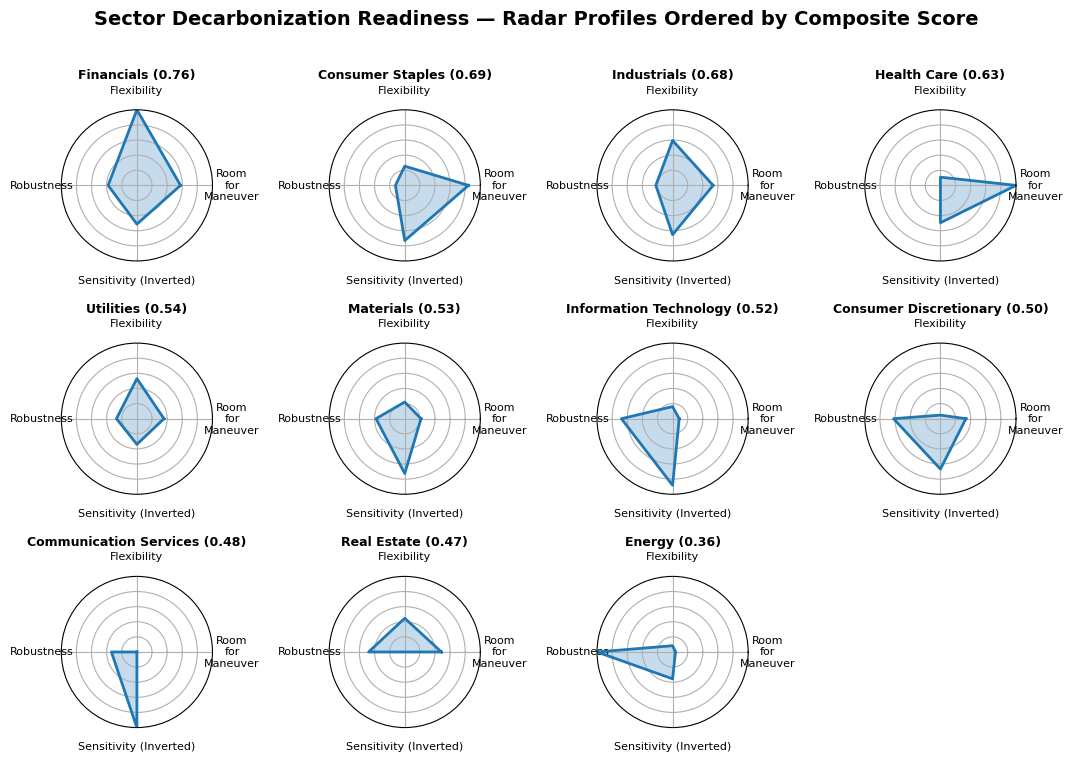

✅ Saved Decarbonization Readiness scores and ordered radar charts.


In [183]:

# --- Load and normalize ---
combined_scores = pd.read_excel("results/combined_sector_scores.xlsx")

def minmax_norm(x):
    if x.max() == x.min():
        return np.ones_like(x)
    return (x - x.min()) / (x.max() - x.min())

cols_to_norm = ["Room for Maneuver", "Flexibility", "Robustness", "Sensitivity_inverted"]
norm_df = combined_scores.copy()
for c in cols_to_norm:
    norm_df[c] = minmax_norm(norm_df[c])

# --- Sort by Composite_Score ---
norm_df = norm_df.sort_values("Composite_Score", ascending=False).reset_index(drop=True)

# --- Radar setup ---
# Adjusted label formatting
labels = [
    "Room\nfor\nManeuver",     # three-line label
    "Flexibility",
    "Robustness",              # we'll rotate this slightly left
    "Sensitivity (Inverted)"
]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the circle

# --- Auto subplot grid ---
n_sectors = len(norm_df)
ncols = 4
nrows = math.ceil(n_sectors / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    subplot_kw=dict(polar=True),
    figsize=(11, 2.5 *nrows)
)
axes = axes.flatten()

# --- Plot radar per sector in score order ---
for i, (_, row) in enumerate(norm_df.iterrows()):
    sector = row["Sector"]
    values = row[cols_to_norm].tolist() + [row[cols_to_norm[0]]]
    ax = axes[i]

    # Plot lines + fill
    ax.plot(angles, values, color="C0", linewidth=2)
    ax.fill(angles, values, color="C0", alpha=0.25)

    # Axis setup
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8, fontweight= 'light')
  
    #ax.tick_params(pad=14)  # default is usually around 5

    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1
)

    # Title = sector name + composite score
    ax.set_title(
        f"{sector} ({row['Composite_Score']:.2f})",
        size=9,
        fontweight="bold",
        y=1.15
    )


# --- Remove empty plots if grid > #sectors ---
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Sector Decarbonization Readiness — Radar Profiles Ordered by Composite Score",
    fontsize=14,
    fontweight="bold",
    y=1.01
)
plt.tight_layout(h_pad=1, w_pad = 0.1)
# --- Save figure ---
fig.savefig(
    "results/decarbonization_radar_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --- Save final scored table ---
norm_df.to_excel("results/decarbonization_readiness_scores.xlsx", index=False)
print("✅ Saved Decarbonization Readiness scores and ordered radar charts.")